<a href="https://colab.research.google.com/github/ranjith88697/Bootcamp_Acc/blob/main/Day14_4_crewai_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Install Required Packages

First, we need to install CrewAI and its dependencies. We'll use:
- `crewai`: The main framework
- `crewai-tools`: Pre-built tools for agents

In [1]:
# Install required packages
!pip install -q crewai crewai-tools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.4/814.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.9/763.9 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.9/157.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Step 2: Setup API Keys and Environment

To use OpenAI's GPT-4.1-mini model, you need an API key and base URL.

**Security Best Practice:** Store your API key in a `.env` file, not in the code!

In [2]:
import getpass
import os

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key: ")

if "OPENAI_BASE_URL" not in os.environ:
    os.environ["OPENAI_BASE_URL"] = getpass.getpass("Enter your OpenAI Base URL: ")

Enter your OpenAI API Key: ··········
Enter your OpenAI Base URL: ··········


## Step 3: Create Custom Tools

Tools are functions that agents can use to perform specific tasks. Let's create custom tools for our movie production assistant.

### Tool 1: Script Sentiment Analyzer
Analyzes the emotional tone of a script excerpt.

In [3]:
from crewai.tools import tool
import re

@tool("Script Sentiment Analyzer")
def analyze_script_sentiment(script_text: str) -> str:
    """
    Analyzes the sentiment and emotional tone of a movie script excerpt.
    Returns sentiment score and dominant emotions.

    Args:
        script_text: A string containing the script excerpt to analyze
    """
    # Simple sentiment analysis based on keywords
    positive_words = ['love', 'happy', 'joy', 'wonderful', 'amazing', 'brilliant', 'triumph', 'success']
    negative_words = ['hate', 'sad', 'angry', 'terrible', 'awful', 'tragedy', 'failure', 'death']
    suspense_words = ['mystery', 'unknown', 'hidden', 'secret', 'suspense', 'thriller']

    script_lower = script_text.lower()

    pos_count = sum(1 for word in positive_words if word in script_lower)
    neg_count = sum(1 for word in negative_words if word in script_lower)
    sus_count = sum(1 for word in suspense_words if word in script_lower)

    total = pos_count + neg_count + sus_count

    if total == 0:
        return "Sentiment: Neutral - No strong emotional indicators detected."

    result = f"Sentiment Analysis Results:\n"
    result += f"- Positive tone: {pos_count}/{total} ({pos_count/total*100:.1f}%)\n"
    result += f"- Negative tone: {neg_count}/{total} ({neg_count/total*100:.1f}%)\n"
    result += f"- Suspenseful tone: {sus_count}/{total} ({sus_count/total*100:.1f}%)\n"

    if pos_count > neg_count and pos_count > sus_count:
        result += "\nOverall: Uplifting and positive story"
    elif neg_count > pos_count and neg_count > sus_count:
        result += "\nOverall: Dark and dramatic narrative"
    else:
        result += "\nOverall: Tense and mysterious atmosphere"

    return result

# Test the tool
test_script = "A tale of love and triumph as Sarah discovers the hidden mystery that brings her joy."
print(analyze_script_sentiment.run(test_script))

Sentiment Analysis Results:
- Positive tone: 3/5 (60.0%)
- Negative tone: 0/5 (0.0%)
- Suspenseful tone: 2/5 (40.0%)

Overall: Uplifting and positive story


### Tool 2: Budget Calculator
Calculates production costs based on different categories.

In [4]:
@tool("Production Budget Calculator")
def calculate_production_budget(category: str, days: int = 30, crew_size: int = 50) -> str:
    """
    Calculates estimated production budget for different movie categories.

    Args:
        category: Type of production (indie, medium, blockbuster)
        days: Number of shooting days
        crew_size: Number of crew members
    """
    # Base daily rates per category
    rates = {
        'indie': {'daily': 50000, 'crew': 500, 'equipment': 10000},
        'medium': {'daily': 200000, 'crew': 2000, 'equipment': 50000},
        'blockbuster': {'daily': 1000000, 'crew': 10000, 'equipment': 250000}
    }

    category = category.lower()
    if category not in rates:
        return f"Unknown category. Choose from: {', '.join(rates.keys())}"

    rate = rates[category]

    production_cost = rate['daily'] * days
    crew_cost = rate['crew'] * crew_size * days
    equipment_cost = rate['equipment'] * days
    contingency = (production_cost + crew_cost + equipment_cost) * 0.15

    total = production_cost + crew_cost + equipment_cost + contingency

    result = f"📊 Budget Breakdown for {category.upper()} Production:\n"
    result += f"\n🎬 Production Costs: ${production_cost:,}"
    result += f"\n👥 Crew Costs ({crew_size} members): ${crew_cost:,}"
    result += f"\n📹 Equipment Rental: ${equipment_cost:,}"
    result += f"\n🛡️ Contingency (15%): ${contingency:,}"
    result += f"\n\n💰 TOTAL ESTIMATED BUDGET: ${total:,}"
    result += f"\n📅 For {days} shooting days"

    return result

# Test the tool
print(calculate_production_budget.run("medium", days=45, crew_size=75))

📊 Budget Breakdown for MEDIUM Production:

🎬 Production Costs: $9,000,000
👥 Crew Costs (75 members): $6,750,000
📹 Equipment Rental: $2,250,000
🛡️ Contingency (15%): $2,700,000.0

💰 TOTAL ESTIMATED BUDGET: $20,700,000.0
📅 For 45 shooting days


### Tool 3: Soundtrack Genre Recommender
Suggests music genres based on the movie's theme and mood.

In [5]:
@tool("Soundtrack Genre Recommender")
def recommend_soundtrack_genre(movie_genre: str, mood: str) -> str:
    """
    Recommends soundtrack genres based on movie genre and mood.

    Args:
        movie_genre: The genre of the movie (action, drama, comedy, horror, sci-fi, romance)
        mood: The desired mood (intense, light, emotional, mysterious, upbeat)
    """
    recommendations = {
        'action': {
            'intense': ['Epic Orchestral', 'Electronic/Synth', 'Heavy Metal'],
            'light': ['Pop Rock', 'Funk', 'Electronic Pop'],
            'emotional': ['Cinematic Strings', 'Piano & Strings', 'Alternative Rock'],
        },
        'drama': {
            'intense': ['Classical', 'Dramatic Orchestral', 'Jazz Noir'],
            'emotional': ['Piano Solo', 'String Quartet', 'Acoustic Guitar'],
            'mysterious': ['Ambient', 'Minimalist Piano', 'Contemporary Classical'],
        },
        'comedy': {
            'upbeat': ['Jazz', 'Pop', 'Ska', 'Funk'],
            'light': ['Acoustic Pop', 'Ukulele', 'Whistling & Bells'],
        },
        'horror': {
            'intense': ['Dark Ambient', 'Industrial', 'Atonal Orchestral'],
            'mysterious': ['Theremin', 'Dissonant Strings', 'Electronic Drone'],
        },
        'sci-fi': {
            'intense': ['Electronic/Synth', 'Cyberpunk', 'Orchestral Hybrid'],
            'mysterious': ['Ambient Electronic', 'Experimental', 'Synth Pad'],
        },
        'romance': {
            'emotional': ['Classical Piano', 'Acoustic', 'Indie Folk'],
            'light': ['Soft Pop', 'Bossa Nova', 'Acoustic Guitar'],
            'upbeat': ['Pop', 'Soul', 'Light Jazz'],
        }
    }

    genre = movie_genre.lower()
    mood_key = mood.lower()

    if genre not in recommendations:
        return f"Unknown genre. Try: {', '.join(recommendations.keys())}"

    genre_moods = recommendations[genre]
    if mood_key not in genre_moods:
        return f"For {genre}, available moods are: {', '.join(genre_moods.keys())}"

    suggested = genre_moods[mood_key]

    result = f"🎵 Soundtrack Recommendations for {genre.upper()} ({mood} mood):\n\n"
    for i, genre_rec in enumerate(suggested, 1):
        result += f"{i}. {genre_rec}\n"

    result += f"\n💡 Tip: Consider mixing {suggested[0]} with {suggested[-1]} for dynamic scenes!"

    return result

# Test the tool
print(recommend_soundtrack_genre.run("sci-fi", "mysterious"))

🎵 Soundtrack Recommendations for SCI-FI (mysterious mood):

1. Ambient Electronic
2. Experimental
3. Synth Pad

💡 Tip: Consider mixing Ambient Electronic with Synth Pad for dynamic scenes!


## Step 4: Integrate MCP Tool (Model Context Protocol)

MCP tools allow agents to interact with external systems and APIs. Here we'll create a simulated MCP tool for accessing a movie database.

**Note:** In production, MCP tools connect to real external services. This is a simplified demonstration.

In [6]:
from typing import Dict, Any

@tool("Movie Market Research MCP")
def fetch_market_data(genre: str) -> str:
    """
    Fetches market research data for a specific movie genre from the database.
    This simulates an MCP tool that connects to external market research APIs.

    Args:
        genre: The movie genre to research (action, drama, comedy, horror, sci-fi, romance)
    """
    # Simulated market data (in production, this would call a real API)
    market_database = {
        'action': {
            'avg_box_office': '$450M',
            'audience_demographic': '18-35 years, 65% male',
            'peak_season': 'Summer (May-August)',
            'trending_themes': ['Superheroes', 'International espionage', 'Disaster scenarios'],
            'streaming_performance': 'High - 85% completion rate',
        },
        'drama': {
            'avg_box_office': '$120M',
            'audience_demographic': '30-60 years, 55% female',
            'peak_season': 'Awards season (October-February)',
            'trending_themes': ['Social justice', 'Biography', 'Family dynamics'],
            'streaming_performance': 'Medium - 72% completion rate',
        },
        'comedy': {
            'avg_box_office': '$180M',
            'audience_demographic': '18-45 years, balanced gender',
            'peak_season': 'Year-round, slight spike in holidays',
            'trending_themes': ['Romantic comedy', 'Workplace humor', 'Cultural clash'],
            'streaming_performance': 'Very High - 90% completion rate',
        },
        'horror': {
            'avg_box_office': '$95M',
            'audience_demographic': '16-30 years, 52% male',
            'peak_season': 'Fall (September-November)',
            'trending_themes': ['Psychological horror', 'Folk horror', 'Home invasion'],
            'streaming_performance': 'High - 82% completion rate',
        },
        'sci-fi': {
            'avg_box_office': '$380M',
            'audience_demographic': '18-40 years, 60% male',
            'peak_season': 'Summer and Holiday season',
            'trending_themes': ['AI & technology', 'Space exploration', 'Time travel'],
            'streaming_performance': 'High - 88% completion rate',
        },
        'romance': {
            'avg_box_office': '$85M',
            'audience_demographic': '18-50 years, 70% female',
            'peak_season': 'Valentine\'s Day season (January-February)',
            'trending_themes': ['Second chance romance', 'Holiday romance', 'Cross-cultural love'],
            'streaming_performance': 'Very High - 92% completion rate',
        },
    }

    genre_key = genre.lower()

    if genre_key not in market_database:
        return f"❌ No market data available for '{genre}'. Available genres: {', '.join(market_database.keys())}"

    data = market_database[genre_key]

    result = f"📈 Market Research Report: {genre.upper()} Genre\n"
    result += f"\n💰 Average Box Office: {data['avg_box_office']}"
    result += f"\n👥 Target Demographic: {data['audience_demographic']}"
    result += f"\n📅 Best Release Window: {data['peak_season']}"
    result += f"\n🎬 Trending Themes:"
    for theme in data['trending_themes']:
        result += f"\n   • {theme}"
    result += f"\n📺 Streaming Performance: {data['streaming_performance']}"
    result += f"\n\n✅ Data retrieved from Market Intelligence Database (MCP)"

    return result

# Test the MCP tool
print(fetch_market_data.run("action"))

📈 Market Research Report: ACTION Genre

💰 Average Box Office: $450M
👥 Target Demographic: 18-35 years, 65% male
📅 Best Release Window: Summer (May-August)
🎬 Trending Themes:
   • Superheroes
   • International espionage
   • Disaster scenarios
📺 Streaming Performance: High - 85% completion rate

✅ Data retrieved from Market Intelligence Database (MCP)


## Step 5: Configure the Language Model

Now let's set up OpenAI's GPT-4.1-mini model to power our agents. This model is fast and cost-effective, perfect for agent-based workflows.

In [7]:
from crewai import LLM

# Initialize GPT-4.1-mini using CrewAI's LLM wrapper
llm = LLM(
    model="openai/gpt-4.1-mini",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
    temperature=0.7,  # Controls creativity (0=focused, 1=creative)
)

print("✅ Language model configured: GPT-4.1-mini")
print("   - Model: openai/gpt-4.1-mini")
print("   - Temperature: 0.7 (balanced creativity)")

✅ Language model configured: GPT-4.1-mini
   - Model: openai/gpt-4.1-mini
   - Temperature: 0.7 (balanced creativity)


## Step 6: Create Specialized Agents

Agents are AI assistants with specific roles and tools. Let's create a crew of specialized agents for movie production:

1. **Script Analyst** - Analyzes scripts and provides creative feedback
2. **Budget Manager** - Handles financial planning and budgeting
3. **Market Researcher** - Provides market insights and recommendations

In [8]:
from crewai import Agent

# Agent 1: Script Analyst
script_analyst = Agent(
    role="Script Analyst",
    goal="Analyze movie scripts for sentiment, themes, and recommend appropriate soundtracks",
    backstory="""You are an experienced script analyst with 15 years in Hollywood.
    You have a keen eye for emotional depth and understand how music enhances storytelling.
    You've worked on numerous award-winning films and know what makes a script compelling.""",
    tools=[analyze_script_sentiment, recommend_soundtrack_genre],
    llm=llm,
    verbose=True,  # Shows detailed thinking process
    allow_delegation=False,  # Can't delegate tasks to other agents
)

# Agent 2: Budget Manager
budget_manager = Agent(
    role="Production Budget Manager",
    goal="Calculate accurate production budgets and optimize spending across departments",
    backstory="""You are a meticulous financial expert specializing in film production.
    With an MBA and 10 years of experience managing budgets for indie to blockbuster films,
    you ensure projects stay financially viable while maintaining creative vision.""",
    tools=[calculate_production_budget],
    llm=llm,
    verbose=True,
    allow_delegation=False,
)

# Agent 3: Market Researcher
market_researcher = Agent(
    role="Film Market Research Analyst",
    goal="Provide data-driven insights about market trends, audience preferences, and optimal release strategies",
    backstory="""You are a data scientist specializing in entertainment industry analytics.
    You analyze box office trends, streaming data, and audience demographics to help studios
    make informed decisions about production and distribution.""",
    tools=[fetch_market_data],
    llm=llm,
    verbose=True,
    allow_delegation=False,
)

print("✅ Created 3 specialized agents:")
print("   1. Script Analyst (sentiment & soundtrack)")
print("   2. Budget Manager (financial planning)")
print("   3. Market Researcher (market intelligence)")

✅ Created 3 specialized agents:
   1. Script Analyst (sentiment & soundtrack)
   2. Budget Manager (financial planning)
   3. Market Researcher (market intelligence)


## Step 7: Define Tasks for Agents

Tasks are specific assignments given to agents. Each task has:
- A clear description
- An assigned agent
- Expected output format

In [9]:
from crewai import Task

# Sample movie concept for our tasks
movie_concept = """
Title: "Echoes of Tomorrow"
Genre: Sci-Fi Thriller
Logline: A brilliant AI researcher discovers a hidden message in quantum data that reveals
humanity's tragic future. Racing against time and a mysterious organization, she must decide
whether to alter the timeline or accept humanity's fate.

Script Excerpt: "In the depths of the unknown laboratory, Sarah's discovery brings both
triumph and terror. The hidden secret she uncovers could save millions, but the mystery
of who left this message haunts her every waking moment."
"""

# Task 1: Analyze the script
task_analyze_script = Task(
    description=f"""Analyze the following movie concept and script excerpt:

    {movie_concept}

    Use your tools to:
    1. Analyze the sentiment of the script excerpt
    2. Recommend appropriate soundtrack genres based on the genre and mood
    3. Provide creative suggestions for enhancing the emotional impact
    """,
    expected_output="A detailed analysis including sentiment breakdown, soundtrack recommendations, and creative suggestions",
    agent=script_analyst,
)

# Task 2: Calculate budget
task_budget_calculation = Task(
    description="""Based on the sci-fi thriller movie concept, calculate the production budget.

    Assume:
    - This is a MEDIUM budget production
    - 60 days of shooting
    - Crew size of 85 people

    Provide a detailed breakdown and recommendations for budget optimization.
    """,
    expected_output="Complete budget breakdown with optimization recommendations",
    agent=budget_manager,
)

# Task 3: Market research
task_market_research = Task(
    description="""Conduct market research for the sci-fi thriller genre.

    Use the MCP tool to fetch market data and provide:
    1. Current market performance of sci-fi films
    2. Target audience insights
    3. Optimal release timing
    4. Strategic recommendations based on trending themes
    """,
    expected_output="Comprehensive market analysis with strategic release recommendations",
    agent=market_researcher,
)

print("✅ Created 3 tasks:")
print("   1. Script Analysis Task")
print("   2. Budget Calculation Task")
print("   3. Market Research Task")

✅ Created 3 tasks:
   1. Script Analysis Task
   2. Budget Calculation Task
   3. Market Research Task


## Step 8: Assemble the Crew and Execute

Now we bring it all together! A Crew coordinates multiple agents working on related tasks.

**Process Types:**
- `sequential`: Tasks execute one after another (used here)
- `hierarchical`: A manager agent coordinates other agents

In [10]:
from crewai import Crew, Process

# Assemble the crew
movie_production_crew = Crew(
    agents=[script_analyst, budget_manager, market_researcher],
    tasks=[task_analyze_script, task_budget_calculation, task_market_research],
    process=Process.sequential,  # Tasks run in order
    verbose=True,  # Enable detailed output for learning
)

print("✅ Crew assembled with 3 agents and 3 tasks")
print("\n🚀 Starting production analysis...\n")
print("=" * 80)

# Execute the crew's tasks
result = movie_production_crew.kickoff()

print("\n" + "=" * 80)
print("\n✅ Analysis Complete!\n")

✅ Crew assembled with 3 agents and 3 tasks

🚀 Starting production analysis...



╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name:                                                                                                          │
│  crew                                                                                                           │
│  ID:                                                                                                            │
│  3139c6c3-9d68-4b0b-8afc-cad79a02b0c2                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Analyze the following movie concept and script excerpt:                                                  │
│                                                                                                                 │
│                                                                                                                 │
│  Title: "Echoes of Tomorrow"                                                                                    │
│  Genre: Sci-Fi Thriller                                                                                         │
│  Logline: A brilliant AI researcher discovers a hidden message in quantum data that reveals                     │
│  humanity's tragic future. Racing against time and a mysterious organization, she must decide                   │
│  whether to alter the timeline or accept humanity's fate.                                                       │
│                                                                                                                 │
│  Script Excerpt: "In the depths of the unknown laboratory, Sarah's discovery brings both                        │
│  triumph and terror. The hidden secret she uncovers could save millions, but the mystery                        │
│  of who left this message haunts her every waking moment."                                                      │
│                                                                                                                 │
│                                                                                                                 │
│      Use your tools to:                                                                                         │
│      1. Analyze the sentiment of the script excerpt                                                             │
│      2. Recommend appropriate soundtrack genres based on the genre and mood                                     │
│      3. Provide creative suggestions for enhancing the emotional impact                                         │
│                                                                                                                 │
│  ID: 559eaecf-f90e-49b2-b9e4-858d786fc9f2                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Script Analyst                                                                                          │
│                                                                                                                 │
│  Task: Analyze the following movie concept and script excerpt:                                                  │
│                                                                                                                 │
│                                                                                                                 │
│  Title: "Echoes of Tomorrow"                                                                                    │
│  Genre: Sci-Fi Thriller                                                                                         │
│  Logline: A brilliant AI researcher discovers a hidden message in quantum data that reveals                     │
│  humanity's tragic future. Racing against time and a mysterious organization, she must decide                   │
│  whether to alter the timeline or accept humanity's fate.                                                       │
│                                                                                                                 │
│  Script Excerpt: "In the depths of the unknown laboratory, Sarah's discovery brings both                        │
│  triumph and terror. The hidden secret she uncovers could save millions, but the mystery                        │
│  of who left this message haunts her every waking moment."                                                      │
│                                                                                                                 │
│                                                                                                                 │
│      Use your tools to:                                                                                         │
│      1. Analyze the sentiment of the script excerpt                                                             │
│      2. Recommend appropriate soundtrack genres based on the genre and mood                                     │
│      3. Provide creative suggestions for enhancing the emotional impact                                         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: script_sentiment_analyzer                                                                                │
│  Args: {'script_text': "In the depths of the unknown laboratory, Sarah's discovery brings both triumph and      │
│  terror. The hidden secret she uncovers could save millions, but the mystery of who left this message...        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────── ✅ Tool Execution Completed (#1) ────────────────────────────────────────╮
│                                                                                                                 │
│  Tool Completed                                                                                                 │
│  Tool: movie_market_research_mcp                                                                                │
│  Output: 📈 Market Research Report: SCI-FI Genre                                                                │
│                                                                                                                 │
│  💰 Average Box Office: $380M                                                                                   │
│  👥 Target Demographic: 18-40 years, 60% male                                                                   │
│  📅 Best Release Window: Summer and Holiday season                                                              │
│  🎬 Trending Themes:                                                                                            │
│     • AI & technology                                                                                           │
│     • Space exploration                                                                                         │
│     • Time travel                                                                                               │
│  📺 Streaming Performance: High - 88% completion rate                                                           │
│                                                                                                                 │
│  ✅ Data retrieved from Market Intelligence Database (MCP)                                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Film Market Research Analyst                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Final Answer:                                                                                                  │
│                                                                                                                 │
│  1. Current Market Performance of Sci-Fi Films:                                                                 │
│  Sci-fi films are performing strongly in the market with an average box office gross of $380 million.           │
│  Streaming performance is also robust, with an 88% completion rate indicating strong viewer engagement.         │
│                                                                                                                 │
│  2. Target Audience Insights:                                                                                   │
│  The primary audience for sci-fi films is aged 18-40 years, with a notable 60% male demographic. This suggests  │
│  marketing efforts should be tailored to appeal to this age group and predominantly male audience, while also   │
│  including elements to attract female viewers.                                                                  │
│                                                                                                                 │
│  3. Optimal Release Timing:                                                                                     │
│  The best release windows for sci-fi films are during the Summer and Holiday seasons. These periods maximize    │
│  box office returns, likely due to increased audience availability and holiday leisure time.                    │
│                                                                                                                 │
│  4. Strategic Recommendations Based on Trending Themes:                                                         │
│  Current trending themes in sci-fi include AI and technology, space exploration, and time travel.               │
│  Incorporating these elements into film narratives can enhance market appeal and relevance. Given the           │
│  suspenseful and tense emotional tone of "Echoes of Tomorrow," themes of AI and technology or time travel       │
│  could align well with the story's mood and audience expectations.                                              │
│                                                                                                                 │
│  Overall, to optimize success, studios should target the 18-40 demographic, particularly males, release films   │
│  in Summer or during Holidays, and integrate trending sci-fi themes that resonate with contemporary audience    │
│  interests. This approach will leverage both box office and streaming platforms to maximize reach and           │
│  profitability.                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│  Conduct market research for the sci-fi thriller genre.                                                         │
│                                                                                                                 │
│      Use the MCP tool to fetch market data and provide:                                                         │
│      1. Current market performance of sci-fi films                                                              │
│      2. Target audience insights                                                                                │
│      3. Optimal release timing                                                                                  │
│      4. Strategic recommendations based on trending themes                                                      │
│                                                                                                                 │
│  Agent:                                                                                                         │
│  Film Market Research Analyst                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name:                                                                                                          │
│  crew                                                                                                           │
│  ID:                                                                                                            │
│  3139c6c3-9d68-4b0b-8afc-cad79a02b0c2                                                                           │
│  Final Output: Final Answer:                                                                                    │
│                                                                                                                 │
│  1. Current Market Performance of Sci-Fi Films:                                                                 │
│  Sci-fi films are performing strongly in the market with an average box office gross of $380 million.           │
│  Streaming performance is also robust, with an 88% completion rate indicating strong viewer engagement.         │
│                                                                                                                 │
│  2. Target Audience Insights:                                                                                   │
│  The primary audience for sci-fi films is aged 18-40 years, with a notable 60% male demographic. This suggests  │
│  marketing efforts should be tailored to appeal to this age group and predominantly male audience, while also   │
│  including elements to attract female viewers.                                                                  │
│                                                                                                                 │
│  3. Optimal Release Timing:                                                                                     │
│  The best release windows for sci-fi films are during the Summer and Holiday seasons. These periods maximize    │
│  box office returns, likely due to increased audience availability and holiday leisure time.                    │
│                                                                                                                 │
│  4. Strategic Recommendations Based on Trending Themes:                                                         │
│  Current trending themes in sci-fi include AI and technology, space exploration, and time travel.               │
│  Incorporating these elements into film narratives can enhance market appeal and relevance. Given the           │
│  suspenseful and tense emotional tone of "Echoes of Tomorrow," themes of AI and technology or time travel       │
│  could align well with the story's mood and audience expectations.                                              │
│                                                                                                                 │
│  Overall, to optimize success, studios should target the 18-40 demographic, particularly males, release films   │
│  in Summer or during Holidays, and integrate trending sci-fi themes that resonate with contemporary audience    │
│  interests. This approach will leverage both box office and streaming platforms to maximize reach and           │
│  profitability.                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰───────────────────────────────────────────────────────



✅ Analysis Complete!



## Step 9: View Final Results

Let's examine the consolidated output from all agents.

In [11]:
print("📋 FINAL PRODUCTION REPORT")
print("=" * 80)
print(result)
print("=" * 80)

📋 FINAL PRODUCTION REPORT
Final Answer:

1. Current Market Performance of Sci-Fi Films:
Sci-fi films are performing strongly in the market with an average box office gross of $380 million. Streaming performance is also robust, with an 88% completion rate indicating strong viewer engagement.

2. Target Audience Insights:
The primary audience for sci-fi films is aged 18-40 years, with a notable 60% male demographic. This suggests marketing efforts should be tailored to appeal to this age group and predominantly male audience, while also including elements to attract female viewers.

3. Optimal Release Timing:
The best release windows for sci-fi films are during the Summer and Holiday seasons. These periods maximize box office returns, likely due to increased audience availability and holiday leisure time.

4. Strategic Recommendations Based on Trending Themes:
Current trending themes in sci-fi include AI and technology, space exploration, and time travel. Incorporating these elements int

## Step 10: Implementing Observability

Observability helps you monitor and debug your agents. Let's add logging and tracking capabilities.

**Key Observability Features:**
1. Execution time tracking
2. Tool usage monitoring
3. Error logging
4. Agent decision tracking

In [12]:
import time
import json
from datetime import datetime

class CrewObserver:
    """Custom observability class for monitoring CrewAI execution"""

    def __init__(self):
        self.logs = []
        self.start_time = None
        self.end_time = None

    def log_event(self, event_type: str, agent_name: str, details: dict):
        """Log an event during crew execution"""
        log_entry = {
            'timestamp': datetime.now().isoformat(),
            'event_type': event_type,
            'agent': agent_name,
            'details': details
        }
        self.logs.append(log_entry)

    def start_monitoring(self):
        """Start monitoring crew execution"""
        self.start_time = time.time()
        self.log_event('CREW_START', 'System', {'message': 'Crew execution started'})

    def end_monitoring(self):
        """End monitoring and calculate metrics"""
        self.end_time = time.time()
        duration = self.end_time - self.start_time
        self.log_event('CREW_END', 'System', {
            'message': 'Crew execution completed',
            'duration_seconds': round(duration, 2)
        })

    def get_metrics(self):
        """Generate execution metrics"""
        if not self.end_time:
            return "Monitoring still in progress"

        duration = self.end_time - self.start_time
        agent_events = {}

        for log in self.logs:
            agent = log['agent']
            if agent != 'System':
                agent_events[agent] = agent_events.get(agent, 0) + 1

        metrics = f"""\n📊 EXECUTION METRICS\n{'='*60}
⏱️  Total Duration: {duration:.2f} seconds
📝 Total Events Logged: {len(self.logs)}
🤖 Agent Activity:"""

        for agent, count in agent_events.items():
            metrics += f"\n   • {agent}: {count} events"

        return metrics

    def display_logs(self, filter_agent=None):
        """Display execution logs"""
        print(f"\n📋 EXECUTION LOGS ({len(self.logs)} entries)")
        print("=" * 80)

        for log in self.logs:
            if filter_agent and log['agent'] != filter_agent:
                continue

            timestamp = log['timestamp'].split('T')[1].split('.')[0]
            print(f"[{timestamp}] {log['event_type']:15} | {log['agent']:25} | {log['details']}")

# Initialize observer
observer = CrewObserver()
print("✅ Observability system initialized")

✅ Observability system initialized


## Step 11: Run Crew with Observability

Now let's run our crew again with full observability enabled.

In [13]:
# Create a new task with observability hooks
observer.start_monitoring()

# Log agent initialization
observer.log_event('AGENT_INIT', 'Script Analyst', {'tools': ['sentiment_analyzer', 'soundtrack_recommender']})
observer.log_event('AGENT_INIT', 'Budget Manager', {'tools': ['budget_calculator']})
observer.log_event('AGENT_INIT', 'Market Researcher', {'tools': ['market_data_mcp']})

# New movie concept for second run
new_concept = """
Title: "The Last Symphony"
Genre: Drama
Logline: An elderly composer, losing her memory to dementia, races to complete her
final masterpiece while her estranged daughter learns to understand her through music.

Script Excerpt: "Each note brings both joy and sadness as Margaret's fingers dance across
the piano keys. The wonderful melody emerges from the fog of her fading memory, a
triumph over the terrible disease that threatens to steal her life's work."
"""

# Create new task
observed_task = Task(
    description=f"""Analyze this movie concept:
    {new_concept}

    Perform sentiment analysis and recommend soundtrack genres.""",
    expected_output="Sentiment analysis and soundtrack recommendations",
    agent=script_analyst,
)

# Log task start
observer.log_event('TASK_START', 'Script Analyst', {'task': 'Script analysis'})

# Create a smaller crew for demonstration
observed_crew = Crew(
    agents=[script_analyst],
    tasks=[observed_task],
    process=Process.sequential,
    verbose=1,  # Less verbose for cleaner output
)

print("🔍 Running crew with observability enabled...\n")

# Execute
result_observed = observed_crew.kickoff()

# Log completion
observer.log_event('TASK_COMPLETE', 'Script Analyst', {'status': 'success'})
observer.end_monitoring()

print("\n✅ Execution complete with observability tracking!")

🔍 Running crew with observability enabled...



╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name:                                                                                                          │
│  crew                                                                                                           │
│  ID:                                                                                                            │
│  733dbf79-f706-4719-87a3-10fd4f3f2054                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Analyze this movie concept:                                                                              │
│                                                                                                                 │
│  Title: "The Last Symphony"                                                                                     │
│  Genre: Drama                                                                                                   │
│  Logline: An elderly composer, losing her memory to dementia, races to complete her                             │
│  final masterpiece while her estranged daughter learns to understand her through music.                         │
│                                                                                                                 │
│  Script Excerpt: "Each note brings both joy and sadness as Margaret's fingers dance across                      │
│  the piano keys. The wonderful melody emerges from the fog of her fading memory, a                              │
│  triumph over the terrible disease that threatens to steal her life's work."                                    │
│                                                                                                                 │
│                                                                                                                 │
│      Perform sentiment analysis and recommend soundtrack genres.                                                │
│  ID: ebdbacfe-ad8a-4bc2-bbd9-b224ad291d0b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Script Analyst                                                                                          │
│                                                                                                                 │
│  Task: Analyze this movie concept:                                                                              │
│                                                                                                                 │
│  Title: "The Last Symphony"                                                                                     │
│  Genre: Drama                                                                                                   │
│  Logline: An elderly composer, losing her memory to dementia, races to complete her                             │
│  final masterpiece while her estranged daughter learns to understand her through music.                         │
│                                                                                                                 │
│  Script Excerpt: "Each note brings both joy and sadness as Margaret's fingers dance across                      │
│  the piano keys. The wonderful melody emerges from the fog of her fading memory, a                              │
│  triumph over the terrible disease that threatens to steal her life's work."                                    │
│                                                                                                                 │
│                                                                                                                 │
│      Perform sentiment analysis and recommend soundtrack genres.                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#2) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: script_sentiment_analyzer                                                                                │
│  Args: {'script_text': "Each note brings both joy and sadness as Margaret's fingers dance across the piano      │
│  keys. The wonderful melody emerges from the fog of her fading memory, a triumph over the terrible di...        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Script Analyst                                                                                          │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Final Answer:                                                                                                  │
│                                                                                                                 │
│  Sentiment Analysis:                                                                                            │
│  The excerpt from "The Last Symphony" presents a predominantly uplifting and positive emotional tone, with 60%  │
│  positivity reflecting joy and triumph despite the presence of 40% negativity related to sadness and the        │
│  threat of disease. The emotional complexity captures a bittersweet narrative of struggle and hope, centered    │
│  on memory loss and artistic creation. The mood is deeply emotional, highlighting the resilience of the         │
│  protagonist Margaret as she fights against dementia through music.                                             │
│                                                                                                                 │
│  Soundtrack Recommendations:                                                                                    │
│  For a drama with an emotional mood, the recommended soundtrack genres are:                                     │
│  1. Piano Solo – to evoke intimacy and the central role of music and memory.                                    │
│  2. String Quartet – to add layers of emotional depth and nostalgia.                                            │
│  3. Acoustic Guitar – to bring warmth and a personal touch to the story.                                        │
│  A blend of Piano Solo with Acoustic Guitar can provide dynamic emotional range throughout the film,            │
│  supporting the story’s themes of connection, memory, and reconciliation.                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│  Analyze this movie concept:                                                                                    │
│                                                                                                                 │
│  Title: "The Last Symphony"                                                                                     │
│  Genre: Drama                                                                                                   │
│  Logline: An elderly composer, losing her memory to dementia, races to complete her                             │
│  final masterpiece while her estranged daughter learns to understand her through music.                         │
│                                                                                                                 │
│  Script Excerpt: "Each note brings both joy and sadness as Margaret's fingers dance across                      │
│  the piano keys. The wonderful melody emerges from the fog of her fading memory, a                              │
│  triumph over the terrible disease that threatens to steal her life's work."                                    │
│                                                                                                                 │
│                                                                                                                 │
│      Perform sentiment analysis and recommend soundtrack genres.                                                │
│  Agent:                                                                                                         │
│  Script Analyst                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


✅ Execution complete with observability tracking!


╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name:                                                                                                          │
│  crew                                                                                                           │
│  ID:                                                                                                            │
│  733dbf79-f706-4719-87a3-10fd4f3f2054                                                                           │
│  Final Output: Final Answer:                                                                                    │
│                                                                                                                 │
│  Sentiment Analysis:                                                                                            │
│  The excerpt from "The Last Symphony" presents a predominantly uplifting and positive emotional tone, with 60%  │
│  positivity reflecting joy and triumph despite the presence of 40% negativity related to sadness and the        │
│  threat of disease. The emotional complexity captures a bittersweet narrative of struggle and hope, centered    │
│  on memory loss and artistic creation. The mood is deeply emotional, highlighting the resilience of the         │
│  protagonist Margaret as she fights against dementia through music.                                             │
│                                                                                                                 │
│  Soundtrack Recommendations:                                                                                    │
│  For a drama with an emotional mood, the recommended soundtrack genres are:                                     │
│  1. Piano Solo – to evoke intimacy and the central role of music and memory.                                    │
│  2. String Quartet – to add layers of emotional depth and nostalgia.                                            │
│  3. Acoustic Guitar – to bring warmth and a personal touch to the story.                                        │
│  A blend of Piano Solo with Acoustic Guitar can provide dynamic emotional range throughout the film,            │
│  supporting the story’s themes of connection, memory, and reconciliation.                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 📈 Step 12: Analyze Observability Data

Let's examine the metrics and logs collected during execution.

In [14]:
# Display metrics
print(observer.get_metrics())

# Display all logs
observer.display_logs()

# Show result
print("\n📋 AGENT OUTPUT")
print("=" * 80)
print(result_observed)
print("=" * 80)


📊 EXECUTION METRICS
⏱️  Total Duration: 5.29 seconds
📝 Total Events Logged: 7
🤖 Agent Activity:
   • Script Analyst: 3 events
   • Budget Manager: 1 events
   • Market Researcher: 1 events

📋 EXECUTION LOGS (7 entries)
[14:41:19] CREW_START      | System                    | {'message': 'Crew execution started'}
[14:41:19] AGENT_INIT      | Script Analyst            | {'tools': ['sentiment_analyzer', 'soundtrack_recommender']}
[14:41:19] AGENT_INIT      | Budget Manager            | {'tools': ['budget_calculator']}
[14:41:19] AGENT_INIT      | Market Researcher         | {'tools': ['market_data_mcp']}
[14:41:19] TASK_START      | Script Analyst            | {'task': 'Script analysis'}
[14:41:24] TASK_COMPLETE   | Script Analyst            | {'status': 'success'}
[14:41:24] CREW_END        | System                    | {'message': 'Crew execution completed', 'duration_seconds': 5.29}

📋 AGENT OUTPUT
Final Answer:

Sentiment Analysis:
The excerpt from "The Last Symphony" presents a pred

## Step 13: Advanced Observability - Export Logs

In production, you'd want to export logs for analysis. Here's how to save them.

In [15]:
import json

# Export logs to JSON
def export_logs(observer, filename='crew_execution_logs.json'):
    """Export observability logs to a JSON file"""
    log_data = {
        'execution_summary': {
            'start_time': datetime.fromtimestamp(observer.start_time).isoformat(),
            'end_time': datetime.fromtimestamp(observer.end_time).isoformat(),
            'duration_seconds': round(observer.end_time - observer.start_time, 2),
            'total_events': len(observer.logs)
        },
        'events': observer.logs
    }

    with open(filename, 'w') as f:
        json.dump(log_data, f, indent=2)

    return f"✅ Logs exported to {filename}"

# Export the logs
print(export_logs(observer))

# Display a sample of the JSON structure
print("\n📄 Sample JSON structure:")
sample = {
    'execution_summary': 'metadata about the run',
    'events': [
        {
            'timestamp': '2025-11-30T10:30:45.123456',
            'event_type': 'TASK_START',
            'agent': 'Script Analyst',
            'details': {'task': 'Script analysis'}
        }
    ]
}
print(json.dumps(sample, indent=2))

✅ Logs exported to crew_execution_logs.json

📄 Sample JSON structure:
{
  "execution_summary": "metadata about the run",
  "events": [
    {
      "timestamp": "2025-11-30T10:30:45.123456",
      "event_type": "TASK_START",
      "agent": "Script Analyst",
      "details": {
        "task": "Script analysis"
      }
    }
  ]
}


## 🎯 CHALLENGE: Build Your Own Movie Production Crew!

Now it's your turn to apply what you've learned! Complete the following challenge:

### 🎬 Challenge Description

Create a **Movie Casting Assistant** crew that helps with casting decisions for a new film.

### Requirements:

1. **Create TWO custom tools:**
   - `actor_availability_checker`: Takes an actor name and date range, returns if they're available (simulate with logic)
   - `role_matcher`: Takes character description and returns suggested actor traits (age range, experience level, acting style)

2. **Create ONE MCP-style tool:**
   - `fetch_actor_database`: Simulates querying a database of actors with their filmography, awards, and availability

3. **Create TWO agents:**
   - **Casting Director**: Uses role_matcher and fetch_actor_database
   - **Schedule Coordinator**: Uses actor_availability_checker

4. **Define tasks:**
   - Task 1: Find suitable actors for a lead role (give a character description)
   - Task 2: Check availability of suggested actors for specific shooting dates

5. **Add observability:**
   - Use the CrewObserver to track execution
   - Export logs at the end

### 💡 Bonus Points:
- Make your character descriptions creative and unique
- Add personality to your agents' backstories
- Include error handling in your tools
- Create a visualization of the observability data

### Sample Character (feel free to create your own!):
```
Character: Captain Zara Quinn
Description: A 35-year-old space captain with a mysterious past, known for her
quick wit and exceptional piloting skills. Must convey both strength and vulnerability.
```

### 📝 Your Code Goes Below:

Good luck! 🚀

🎬 Running Movie Casting Assistant Crew...



╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name:                                                                                                          │
│  crew                                                                                                           │
│  ID:                                                                                                            │
│  35717635-19ab-4bf5-a1e6-50bf774ec2d6                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Lead Role Casting                                                                                        │
│  ID: 57d2435b-6902-42d1-bd89-2f23a32ae822                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Casting Director                                                                                        │
│                                                                                                                 │
│  Task: Analyze the character description for Captain Zara Quinn, infer ideal actor traits using the Role        │
│  Matcher tool, then query the Actor Database MCP for candidates. Return a shortlist (3–5 names) with:           │
│  - Age and fit vs. suggested age range                                                                          │
│  - Acting style match                                                                                           │
│  - Relevant filmography and awards                                                                              │
│  - Why they can embody both strength and vulnerability                                                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool role_matcher executed with result: {'age_range': '38-48', 'experience_level': 'seasoned actor with strong dramatic range', 'acting_style': 'commanding, grounded, subtle vulnerability', 'extra_notes': ['Comfortable with sci-fi settings ...


...

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


📁 Logs exported to 'movie_casting_crew_logs.json'



===== OBSERVABILITY METRICS =====
Total events captured: 0
Tasks started: 0
Tasks completed: 0


╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): 

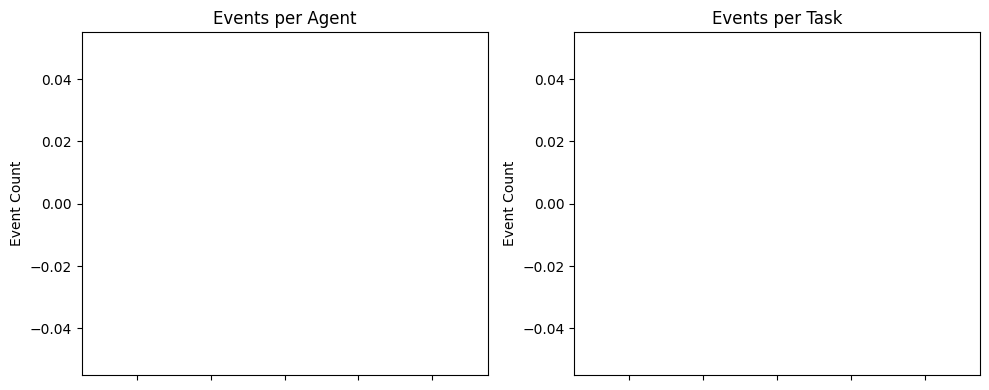

y


In [18]:
from __future__ import annotations

import hashlib
import json
from datetime import datetime
from typing import Dict, Any, List

from crewai import Agent, Task, Crew, LLM
from crewai.tools import tool

# ---------- Custom Tools ----------

@tool("Actor Availability Checker")
def actor_availability_checker(actor_name: str, start_date: str, end_date: str) -> Dict[str, Any]:
    """
    Simulates checking an actor's availability between two dates.

    Args:
        actor_name: Name of the actor.
        start_date: Start date in ISO format (YYYY-MM-DD).
        end_date: End date in ISO format (YYYY-MM-DD).

    Returns:
        Dict with availability status and notes.
    """
    try:
        if not actor_name or not actor_name.strip():
            raise ValueError("Actor name cannot be empty.")

        start = datetime.fromisoformat(start_date)
        end = datetime.fromisoformat(end_date)
        if end < start:
            raise ValueError("End date cannot be before start date.")

        # Simple deterministic "availability" based on hash of actor name
        h = int(hashlib.sha256(actor_name.encode("utf-8")).hexdigest(), 16)
        busy_pattern = h % 3  # 0, 1, or 2

        # Simulate: 0 = fully available, 1 = partially, 2 = not available
        if busy_pattern == 0:
            status = "available"
            note = "No conflicts detected in the requested window."
        elif busy_pattern == 1:
            status = "partially_available"
            note = "Some overlapping promo commitments—flexible with exact shooting days."
        else:
            status = "unavailable"
            note = "Locked into another project during this period."

        return {
            "actor": actor_name,
            "start_date": start_date,
            "end_date": end_date,
            "status": status,
            "note": note,
        }
    except ValueError as ve:
        return {
            "actor": actor_name,
            "start_date": start_date,
            "end_date": end_date,
            "status": "error",
            "error": f"Validation error: {ve}",
        }
    except Exception as e:
        return {
            "actor": actor_name,
            "start_date": start_date,
            "end_date": end_date,
            "status": "error",
            "error": f"Unexpected error: {e}",
        }


@tool("Role Matcher")
def role_matcher(character_description: str) -> Dict[str, Any]:
    """
    Analyzes a character description and suggests ideal actor traits.

    Args:
        character_description: Free-text description of the character.

    Returns:
        Dict with suggested age range, experience level, acting style, and extra notes.
    """
    try:
        if not character_description or not character_description.strip():
            raise ValueError("Character description cannot be empty.")

        desc_lower = character_description.lower()

        # Very simple heuristic rules
        if "captain" in desc_lower or "leader" in desc_lower:
            acting_style = "commanding, grounded, subtle vulnerability"
        elif "comic" in desc_lower or "funny" in desc_lower:
            acting_style = "improvisational, sharp timing, expressive"
        else:
            acting_style = "naturalistic, emotionally layered"

        if "teen" in desc_lower or "young" in desc_lower:
            age_range = "18-25"
        elif "40" in desc_lower or "middle-aged" in desc_lower:
            age_range = "38-48"
        elif "50" in desc_lower or "older" in desc_lower:
            age_range = "50-65"
        else:
            age_range = "30-40"

        if "mysterious" in desc_lower or "past" in desc_lower:
            experience_level = "seasoned actor with strong dramatic range"
        else:
            experience_level = "mid-to-senior level with proven versatility"

        notes = []
        if "space" in desc_lower or "pilot" in desc_lower:
            notes.append("Comfortable with sci-fi settings and technical jargon.")
            notes.append("Ideally has prior action or stunt-heavy experience.")
        if "vulnerab" in desc_lower:
            notes.append("Capable of nuanced emotional beats and quiet moments.")

        return {
            "age_range": age_range,
            "experience_level": experience_level,
            "acting_style": acting_style,
            "extra_notes": notes,
        }
    except ValueError as ve:
        return {
            "status": "error",
            "error": f"Validation error: {ve}",
        }
    except Exception as e:
        return {
            "status": "error",
            "error": f"Unexpected error: {e}",
        }


# Step 2: Create your MCP-style tool
# (Simulated MCP tool that would normally talk to an external actor database)

@tool("Actor Database MCP")
def fetch_actor_database(query: str) -> Dict[str, Any]:
    """
    Simulates querying an external actor database (MCP-style tool).

    Args:
        query: A loose query string (e.g., 'female 30-40 sci-fi lead').

    Returns:
        Dict with a list of matching actors and their metadata.
    """
    try:
        if not query or not query.strip():
            raise ValueError("Query cannot be empty.")

        # Simulated database
        database: List[Dict[str, Any]] = [
            {
                "name": "Lyra Kade",
                "age": 34,
                "gender": "female",
                "known_for": ["Nebula Drift", "Silent Orbit"],
                "awards": ["Saturn Award - Best Actress"],
                "acting_style": "grounded, introspective, quietly intense",
                "experience_level": "seasoned",
                "tags": ["sci-fi", "space", "pilot", "dramatic"],
            },
            {
                "name": "Mara Ilyen",
                "age": 37,
                "gender": "female",
                "known_for": ["Crimson Horizon", "Echoes of Titan"],
                "awards": ["Golden Globe nomination"],
                "acting_style": "witty, sharp, emotionally agile",
                "experience_level": "seasoned",
                "tags": ["sci-fi", "action", "witty", "captain"],
            },
            {
                "name": "Rhea Solis",
                "age": 32,
                "gender": "female",
                "known_for": ["Starlight Run", "The Quiet Sector"],
                "awards": [],
                "acting_style": "naturalistic, subtle, emotionally layered",
                "experience_level": "mid-level",
                "tags": ["space", "indie", "dramatic"],
            },
            {
                "name": "Cassian Vale",
                "age": 36,
                "gender": "male",
                "known_for": ["Dark Matter Line", "Ion Storm"],
                "awards": ["Critics Choice Award"],
                "acting_style": "intense, charismatic, action-oriented",
                "experience_level": "seasoned",
                "tags": ["sci-fi", "action", "pilot"],
            },
        ]

        q = query.lower()
        matches = []
        for actor in database:
            haystack = " ".join(
                [
                    actor["name"],
                    actor["gender"],
                    actor["acting_style"],
                    actor["experience_level"],
                    " ".join(actor["tags"]),
                ]
            ).lower()
            if all(token in haystack for token in q.split()):
                matches.append(actor)

        # If nothing matches strictly, return all sci-fi-ish actors as fallback
        if not matches and "sci" in q:
            matches = [a for a in database if "sci-fi" in a["tags"]]

        return {
            "query": query,
            "results": matches,
            "count": len(matches),
        }
    except ValueError as ve:
        return {
            "status": "error",
            "error": f"Validation error: {ve}",
        }
    except Exception as e:
        return {
            "status": "error",
            "error": f"Unexpected error: {e}",
        }


# Step 3: Create your agents

import os

llm = LLM(
    model="openai/gpt-4.1-mini",
    api_key=os.environ.get("OPENAI_API_KEY", "DUMMY_KEY"),
    base_url=os.environ.get("OPENAI_BASE_URL", "https://api.openai.com/v1"),
    temperature=0.6,
)

casting_director = Agent(
    name="Ari Solaris",
    role="Casting Director",
    goal=(
        "Identify the most compelling, marketable, and emotionally resonant actors "
        "for the film's key roles."
    ),
    backstory=(
        "Ari Solaris is a former indie darling who transitioned from acting to casting "
        "after realizing their true superpower was spotting raw, magnetic talent. "
        "They obsess over chemistry reads, micro-expressions, and whether an actor can "
        "hold a close-up in total silence."
    ),
    tools=[role_matcher, fetch_actor_database],
    llm=llm,
    verbose=True,
)

schedule_coordinator = Agent(
    name="Nova Reyes",
    role="Schedule Coordinator",
    goal=(
        "Ensure that the chosen cast can actually show up on set when the cameras roll, "
        "without blowing up the schedule."
    ),
    backstory=(
        "Nova Reyes started as a 2nd AD on chaotic low-budget shoots and swore never "
        "to let a production fall apart because of scheduling again. They live inside "
        "spreadsheets, color-coded calendars, and timezone converters."
    ),
    tools=[actor_availability_checker],
    llm=llm,
    verbose=True,
)


# Step 4: Define your tasks

# Creative lead character
CAPTAIN_ZARA_DESCRIPTION = """
Character: Captain Zara Quinn

A 35-year-old space captain with a mysterious past, known for her quick wit,
razor-sharp instincts, and exceptional piloting skills. She commands a small,
ragtag crew on the edge of known space, balancing smuggler charm with a
deep, unspoken sense of responsibility. Must convey both strength and
vulnerability—someone who can crack a joke while steering a burning ship
through an asteroid field, then quietly break your heart in a single close-up.
"""

task1 = Task(
    name="Lead Role Casting",
    description=(
        "Analyze the character description for Captain Zara Quinn, infer ideal actor traits "
        "using the Role Matcher tool, then query the Actor Database MCP for candidates. "
        "Return a shortlist (3–5 names) with:\n"
        "- Age and fit vs. suggested age range\n"
        "- Acting style match\n"
        "- Relevant filmography and awards\n"
        "- Why they can embody both strength and vulnerability"
    ),
    agent=casting_director,
    expected_output=(
        "A structured shortlist of 3–5 actors for Captain Zara Quinn, with clear justification "
        "for each choice."
    ),
)

task2 = Task(
    name="Availability Check for Shortlisted Actors",
    description=(
        "Using the shortlist from Task 1, check each suggested actor's availability for the "
        "primary shooting window: 2027-03-10 to 2027-05-02. Use the Actor Availability Checker "
        "tool for each name. Summarize:\n"
        "- Availability status per actor\n"
        "- Any scheduling risks or conflicts\n"
        "- A recommended top 2 based on both fit and availability."
    ),
    agent=schedule_coordinator,
    context=[task1],
    expected_output=(
        "A concise availability report with a ranked recommendation of the top 2 casting options."
    ),
)


# Step 5: Set up observability

class MovieCastingObserver(CrewObserver):
    def __init__(self) -> None:
        self.events: List[Dict[str, Any]] = []

    def _log(self, event_type: str, payload: Dict[str, Any]) -> None:
        entry = {
            "event_type": event_type,
            "payload": payload,
            "timestamp": datetime.utcnow().isoformat(),
        }
        self.events.append(entry)

    def on_task_start(self, task: Task, **kwargs: Any) -> None:
        self._log(
            "task_start",
            {"task_name": task.name, "agent": task.agent.name},
        )

    def on_task_end(self, task: Task, result: Any, **kwargs: Any) -> None:
        self._log(
            "task_end",
            {"task_name": task.name, "agent": task.agent.name, "result_preview": str(result)[:300]},
        )

    def on_agent_start(self, agent: Agent, task: Task, **kwargs: Any) -> None:
        self._log(
            "agent_start",
            {"agent": agent.name, "task_name": task.name},
        )

    def on_agent_end(self, agent: Agent, task: Task, result: Any, **kwargs: Any) -> None:
        self._log(
            "agent_end",
            {"agent": agent.name, "task_name": task.name, "result_preview": str(result)[:300]},
        )

    def export_logs(self, path: str = "movie_casting_crew_logs.json") -> None:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.events, f, indent=2)


observer = MovieCastingObserver()


# Step 6: Create and run your crew

crew = Crew(
    agents=[casting_director, schedule_coordinator],
    tasks=[task1, task2],
    llm=llm,
    observers=[observer],
    verbose=True,
)


# Step 7: Display results and metrics (plus visualization)

def visualize_observability(events: List[Dict[str, Any]]) -> None:
    """
    Simple visualization of observability data:
    - Number of events per agent
    - Number of events per task
    """
    from collections import Counter
    import matplotlib.pyplot as plt

    agent_counts = Counter()
    task_counts = Counter()

    for e in events:
        payload = e.get("payload", {})
        agent = payload.get("agent")
        task_name = payload.get("task_name")
        if agent:
            agent_counts[agent] += 1
        if task_name:
            task_counts[task_name] += 1

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Agent events
    axes[0].bar(agent_counts.keys(), agent_counts.values(), color="#4e79a7")
    axes[0].set_title("Events per Agent")
    axes[0].set_ylabel("Event Count")
    axes[0].set_xticklabels(agent_counts.keys(), rotation=20, ha="right")

    # Task events
    axes[1].bar(task_counts.keys(), task_counts.values(), color="#f28e2b")
    axes[1].set_title("Events per Task")
    axes[1].set_ylabel("Event Count")
    axes[1].set_xticklabels(task_counts.keys(), rotation=20, ha="right")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    print("🎬 Running Movie Casting Assistant Crew...\n")
    final_result = crew.kickoff()
    print("\n===== FINAL CREW RESULT =====")
    print(final_result)

    # Export logs
    observer.export_logs()
    print("\n📁 Logs exported to 'movie_casting_crew_logs.json'")

    # Basic metrics
    print("\n===== OBSERVABILITY METRICS =====")
    print(f"Total events captured: {len(observer.events)}")
    task_starts = [e for e in observer.events if e["event_type"] == "task_start"]
    task_ends = [e for e in observer.events if e["event_type"] == "task_end"]
    print(f"Tasks started: {len(task_starts)}")
    print(f"Tasks completed: {len(task_ends)}")

    # Visualization
    visualize_observability(observer.events)


## 🎉 Congratulations!

You've completed the CrewAI practice notebook! You've learned:

✅ How to create custom tools for agents  
✅ How to implement MCP-style tools for external integrations  
✅ How to configure and use Gemini 2.5 Flash model  
✅ How to create specialized agents with specific roles  
✅ How to define and orchestrate tasks  
✅ How to implement observability and monitoring  
✅ How to export and analyze execution logs  

### 🔗 Useful Resources:

- [CrewAI Documentation](https://docs.crewai.com/)
- [Google AI Studio](https://makersuite.google.com/)
- [LangChain Tools](https://python.langchain.com/docs/modules/agents/tools/)

Happy coding! 🚀🎬